# Mini PyTorch — Custom Autograd Engine
A from-scratch scalar autograd engine inspired by Andrej Karpathy's micrograd.
Supports forward/backward passes, MLP construction, and training on real datasets.

In [1]:
from __future__ import annotations
from typing import Set, Tuple, NamedTuple, Union
import math


class Params:
    """
    A scalar value that tracks its computational history for automatic
    differentiation (reverse-mode autograd).

    Each Params node stores:
      - data   : the forward-pass scalar value
      - grad   : accumulated gradient (∂loss/∂self), zeroed by zero_grad()
      - op     : the operation that produced this node (for backward dispatch)
      - label  : human-readable name, used only for graph visualisation
    """

    def __init__(
        self,
        data: float,
        _children: tuple = (),
        op: str = "",
        label: str = "",
    ):
        self.data = float(data)
        self.grad = 0.0          # starts at 0; set to 1.0 only at the loss node
        self.op = op
        self.label = label
        self._children = _children

    def __repr__(self) -> str:
        return (
            f"Params(data={self.data:.4f}, label={self.label!r}, "
            f"op={self.op!r}, grad={self.grad:.4f})"
        )

    # ── Arithmetic ────────────────────────────────────────────────────────────

    def _wrap(self, other: Union[Params, float, int]) -> Params:
        """Coerce a raw scalar to Params so every op works uniformly."""
        return other if isinstance(other, Params) else Params(other, label=str(other))

    def __add__(self, other):
        other = self._wrap(other)
        return Params(
            self.data + other.data,
            (self, other),
            op="+",
            label=f"({self.label}+{other.label})",
        )

    def __radd__(self, other):          # e.g. 0 + p  (needed by sum())
        return self.__add__(other)

    def __mul__(self, other):
        other = self._wrap(other)
        return Params(
            self.data * other.data,
            (self, other),
            op="*",
            label=f"({self.label}*{other.label})",
        )

    def __rmul__(self, other):
        return self.__mul__(other)

    def __neg__(self):
        """Unary negation: -self  →  self * -1 (reuses mul backward)."""
        return self * -1

    def __sub__(self, other):
        """self - other  →  self + (-other)  (reuses add/neg backward)."""
        return self + (-self._wrap(other))

    def __rsub__(self, other):
        return self._wrap(other) + (-self)

    def __truediv__(self, other):
        """self / other  →  self * other**-1  (reuses mul/pow backward)."""
        return self * self._wrap(other) ** -1

    def __rtruediv__(self, other):
        return self._wrap(other) * self ** -1

    def __pow__(self, exp: Union[int, float]):
        """Scalar power: self**exp.  exp must be a Python int or float."""
        if not isinstance(exp, (int, float)):
            raise NotImplementedError("Only int/float exponents are supported.")
        return Params(
            self.data ** exp,
            (self,),
            op=f"**{exp}",
            label=f"({self.label}**{exp})",
        )

    # ── Activation functions ──────────────────────────────────────────────────

    def relu(self) -> Params:
        """ReLU: max(0, x).  Gradient is 1 where x > 0, else 0."""
        return Params(
            max(0.0, self.data),
            (self,),
            op="relu",
            label=f"relu({self.label})",
        )

    def tanh(self) -> Params:
        """Hyperbolic tangent activation.  Output is in (-1, 1)."""
        return Params(
            math.tanh(self.data),
            (self,),
            op="tanh",
            label=f"tanh({self.label})",
        )

    def sigmoid(self) -> Params:
        """Sigmoid activation.  Output is in (0, 1)."""
        s = 1.0 / (1.0 + math.exp(-self.data))
        return Params(s, (self,), op="sigmoid", label=f"σ({self.label})")

    # ── Backward pass ─────────────────────────────────────────────────────────

    def backward(self) -> None:
        """
        Run reverse-mode autodiff from this node (typically the loss).

        Steps:
          1. Build a topological order of all ancestor nodes.
          2. Zero all gradients in the graph (so .backward() is idempotent
             within a single loss computation — but call zero_grad() on the
             *model parameters* between training steps to avoid accumulation).
          3. Set self.grad = 1  (∂loss/∂loss = 1).
          4. Walk the topo list in reverse, applying the chain rule for each op.
        """
        topo: list[Params] = []
        visited: set[Params] = set()

        def build_topo(v: Params) -> None:
            if v not in visited:
                visited.add(v)
                for child in v._children:
                    build_topo(child)
                topo.append(v)

        build_topo(self)

        # Reset all grads in this computation graph
        for node in topo:
            node.grad = 0.0
        self.grad = 1.0  # seed: ∂loss/∂loss = 1

        for v in reversed(topo):
            if v.op == "+":
                # z = a + b  →  ∂z/∂a = 1, ∂z/∂b = 1
                for child in v._children:
                    child.grad += v.grad

            elif v.op == "*":
                # z = a * b  →  ∂z/∂a = b, ∂z/∂b = a
                a, b = v._children
                a.grad += v.grad * b.data
                b.grad += v.grad * a.data

            elif v.op == "relu":
                # ∂relu(x)/∂x = 1 if x > 0 else 0
                (child,) = v._children
                child.grad += v.grad * (1.0 if child.data > 0 else 0.0)

            elif v.op == "tanh":
                # ∂tanh(x)/∂x = 1 - tanh(x)²  (v.data already is tanh(x))
                (child,) = v._children
                child.grad += v.grad * (1.0 - v.data ** 2)

            elif v.op == "sigmoid":
                # ∂σ(x)/∂x = σ(x)·(1 - σ(x))
                (child,) = v._children
                child.grad += v.grad * v.data * (1.0 - v.data)

            elif v.op.startswith("**"):
                # z = x**n  →  ∂z/∂x = n * x**(n-1)
                exp = float(v.op[2:])
                (child,) = v._children
                child.grad += v.grad * exp * (child.data ** (exp - 1))

    def zero_grad(self) -> None:
        """Reset gradient to 0. Call on each parameter before backward()."""
        self.grad = 0.0


In [2]:
class GraphTrace(NamedTuple):
    """Return type of trace(): all nodes and directed edges in the compute graph."""
    nodes: Set[Params]
    edges: Set[Tuple[Params, Params]]


def trace(root: Params) -> GraphTrace:
    """
    DFS from root, collecting every Params node and every (child→parent) edge.
    Used by draw_dot() to build the visualisation.
    """
    nodes: Set[Params] = set()
    edges: Set[Tuple[Params, Params]] = set()

    def build(v: Params) -> None:
        if v not in nodes:
            nodes.add(v)
            for child in v._children:
                edges.add((child, v))
                build(child)

    build(root)
    if not nodes:
        raise ValueError("Empty graph: root has no nodes.")
    return GraphTrace(nodes, edges)


# ── Optional: computational graph visualiser (requires graphviz) ──────────────
# Uncomment the import at the top and this function to enable.
#
# from graphviz import Digraph
#
# def draw_dot(root: Params) -> Digraph:
#     """
#     Render the full computation graph as an SVG using Graphviz.
#     Each value node shows: label | data | grad.
#     Op nodes (ellipses) sit between a value and its children.
#     """
#     dot = Digraph(format="svg", graph_attr={"rankdir": "LR"})
#     graph = trace(root)
#
#     for n in graph.nodes:
#         uid = str(id(n))
#         dot.node(
#             name=uid,
#             label=f"{{ {n.label} | data {n.data:.4f} | grad {n.grad:.4f} }}",
#             shape="record", style="filled", fillcolor="lightblue",
#         )
#         if n.op:
#             op_uid = uid + n.op
#             dot.node(name=op_uid, label=n.op,
#                      shape="ellipse", style="filled", fillcolor="lightcoral")
#             dot.edge(op_uid, uid)          # op → output value
#
#     for child, parent in graph.edges:
#         child_uid = str(id(child))
#         parent_op_uid = (
#             str(id(parent)) + parent.op if parent.op else str(id(parent))
#         )
#         dot.edge(child_uid, parent_op_uid)  # child value → parent op
#
#     return dot


In [3]:
import random


class Neuron:
    """
    A single artificial neuron: out = activation(w · x + b).

    Args:
        nin        : number of inputs (fan-in).
        activation : 'tanh' (default) or 'relu'. The output layer typically
                     uses 'tanh' for binary classification with ±1 targets.
    """

    def __init__(self, nin: int, activation: str = "tanh"):
        # Weights drawn from U(-1, 1); bias initialised to 0 for symmetry
        self.w = [Params(random.uniform(-1, 1), label=f"w{i}") for i in range(nin)]
        self.b = Params(0.0, label="b")
        self.activation = activation

    def __call__(self, x: list) -> Params:
        # Linear combination: z = Σ wᵢ·xᵢ + b
        act = sum(wi * xi for wi, xi in zip(self.w, x)) + self.b
        # Non-linearity
        if self.activation == "tanh":
            return act.tanh()
        elif self.activation == "relu":
            return act.relu()
        else:
            raise ValueError(f"Unknown activation: {self.activation!r}")

    def parameters(self) -> list[Params]:
        """All trainable parameters of this neuron: weights + bias."""
        return self.w + [self.b]

    def __repr__(self) -> str:
        return f"Neuron(nin={len(self.w)}, activation={self.activation!r})"


In [4]:
class Layer:
    """
    A fully-connected layer: nout independent neurons, each with nin inputs.

    Args:
        nin        : number of inputs per neuron.
        nout       : number of neurons (= number of outputs).
        activation : passed through to every Neuron in the layer.
    """

    def __init__(self, nin: int, nout: int, activation: str = "tanh"):
        self.neurons = [Neuron(nin, activation=activation) for _ in range(nout)]

    def __call__(self, x: list):
        outs = [n(x) for n in self.neurons]
        # Unwrap single-element output so callers get a scalar, not a list
        return outs[0] if len(outs) == 1 else outs

    def parameters(self) -> list[Params]:
        return [p for neuron in self.neurons for p in neuron.parameters()]

    def __repr__(self) -> str:
        return f"Layer(neurons={self.neurons})"


In [5]:
class MLP:
    """
    Multi-Layer Perceptron built from Layer objects.

    Args:
        nin   : number of input features.
        nouts : list of layer widths. e.g. [4, 4, 1] → two hidden layers of
                width 4, then a single output neuron.

    All hidden layers use tanh; the output layer also uses tanh so predictions
    are in (-1, 1), matching the ±1-encoded targets used in training.
    """

    def __init__(self, nin: int, nouts: list[int]):
        sizes = [nin] + nouts
        self.layers = [
            Layer(sizes[i], sizes[i + 1], activation="tanh")
            for i in range(len(nouts))
        ]

    def __call__(self, x: list):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self) -> list[Params]:
        return [p for layer in self.layers for p in layer.parameters()]

    def zero_grad(self) -> None:
        """Zero all parameter gradients. Must be called before every backward()."""
        for p in self.parameters():
            p.grad = 0.0

    def __repr__(self) -> str:
        return f"MLP(layers={self.layers})"


## Sanity check — XOR
A quick smoke-test before moving to real datasets.
XOR is not linearly separable, so a network with at least one hidden layer is required.

In [6]:
# XOR dataset  (inputs as raw floats; the training loop wraps them in Params)
xs_xor = [[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]]
ys_xor = [-1.0, 1.0, 1.0, -1.0]   # ±1 labels

random.seed(0)
xor_model = MLP(2, [4, 4, 1])
lr_xor, epochs_xor = 0.1, 500

for epoch in range(epochs_xor):
    # ── Forward ──────────────────────────────────────────────────────────────
    ypred = [xor_model([Params(x1), Params(x2)]) for x1, x2 in xs_xor]

    # MSE loss
    loss = sum((yhat - Params(yt)) ** 2 for yhat, yt in zip(ypred, ys_xor))
    loss = loss * (1.0 / len(xs_xor))

    # ── Backward + update ─────────────────────────────────────────────────────
    xor_model.zero_grad()   # zero grads BEFORE backward to avoid accumulation
    loss.backward()
    for p in xor_model.parameters():
        p.data -= lr_xor * p.grad

    if epoch % 100 == 0 or epoch == epochs_xor - 1:
        print(f"[{epoch:4d}] loss = {loss.data:.6f}")

print("\nXOR predictions:")
for (x1, x2), yt in zip(xs_xor, ys_xor):
    yp = xor_model([Params(x1), Params(x2)])
    print(f"  input ({x1}, {x2}) → target {yt:+.0f}  pred {yp.data:+.4f}")


[   0] loss = 1.010474
[ 100] loss = 0.076913
[ 200] loss = 0.016549
[ 300] loss = 0.008546
[ 400] loss = 0.005637
[ 499] loss = 0.004176

XOR predictions:
  input (0.0, 0.0) → target -1  pred -0.9627
  input (0.0, 1.0) → target +1  pred +0.9291
  input (1.0, 0.0) → target +1  pred +0.9330
  input (1.0, 1.0) → target -1  pred -0.9242


## Datasets — Moons & Iris

In [7]:
%pip install -q matplotlib scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [9]:
import numpy as np
from sklearn.datasets import make_moons, load_iris
import matplotlib.pyplot as plt

np.random.seed(42)
random.seed(42)

# ── Synthetic moons ───────────────────────────────────────────────────────────
X_synth, y_synth = make_moons(n_samples=200, noise=0.15, random_state=42)
y_synth = 2 * y_synth - 1          # {0,1} → {-1,+1}

# ── Iris (first two classes, first two features) ───────────────────────────────
iris = load_iris()
mask = iris.target < 2
X_real = iris.data[mask, :2]
y_real = 2 * iris.target[mask] - 1  # {0,1} → {-1,+1}

# Normalise Iris features to zero mean / unit variance (moons already ~unit scale)
X_real = (X_real - X_real.mean(axis=0)) / X_real.std(axis=0)

datasets = [
    ("Synthetic Moons", X_synth, y_synth),
    ("Real Iris (Sepal)", X_real, y_real),
]


In [10]:
def plot_data(X: np.ndarray, y: np.ndarray, title: str) -> None:
    """Scatter plot of a 2-D dataset with ±1 class labels."""
    plt.figure(figsize=(6, 4))
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="RdYlBu", edgecolors="k", s=30)
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.colorbar(
        ticks=[-1, 1],
        format=plt.FuncFormatter(lambda v, _: "Class -1" if v < 0 else "Class +1"),
    )
    plt.tight_layout()
    plt.show()


def plot_boundary(model, X: np.ndarray, y: np.ndarray, title: str) -> None:
    """
    Render the decision boundary of a custom-autograd MLP on a 2-D dataset.

    Builds a fine meshgrid, runs a forward pass for every grid point, then
    draws a filled contour.  This is slow for large grids; reduce h to speed up.
    """
    h = 0.05   # grid step — smaller → sharper boundary but slower
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5   # FIX: was X[:,0].max()

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h),
    )

    # Forward pass over every grid point
    Z = np.array(
        [model([Params(xi), Params(yi)]).data for xi, yi in zip(xx.ravel(), yy.ravel())]
    ).reshape(xx.shape)

    plt.figure(figsize=(6, 4))
    plt.contourf(xx, yy, Z, levels=50, cmap="RdYlBu", alpha=0.7)
    plt.contour(xx, yy, Z, levels=[0], colors="k", linewidths=1.5)   # decision boundary
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="RdYlBu", edgecolors="k", s=30)
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.tight_layout()
    plt.show()


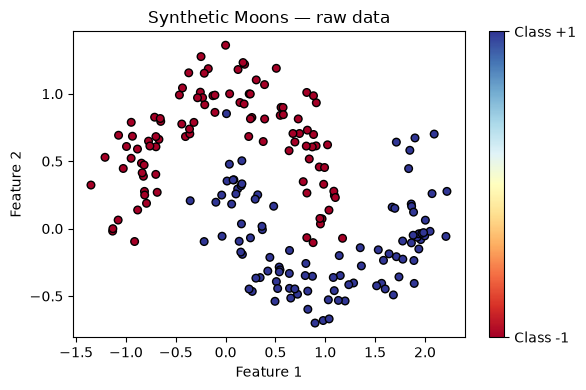

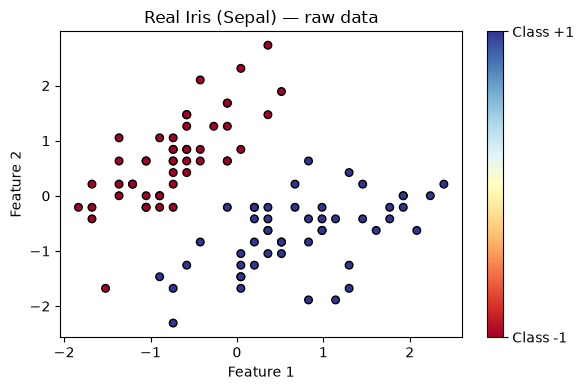

In [11]:
for name, X, y in datasets:
    plot_data(X, y, f"{name} — raw data")



  Training on: Synthetic Moons
  [  0] loss = 0.981992  acc = 79.5%
  [ 50] loss = 0.116258  acc = 92.5%
  [100] loss = 0.043409  acc = 98.0%
  [150] loss = 0.032606  acc = 99.0%
  [200] loss = 0.032633  acc = 99.0%
  [250] loss = 0.022736  acc = 99.0%
  [299] loss = 0.024294  acc = 99.0%


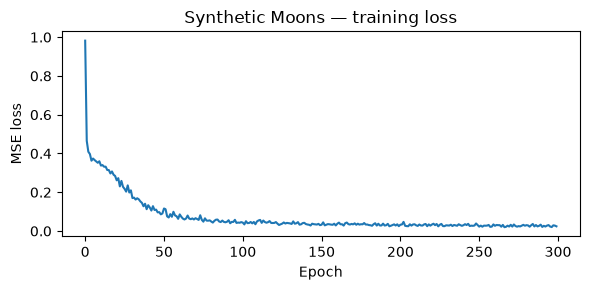

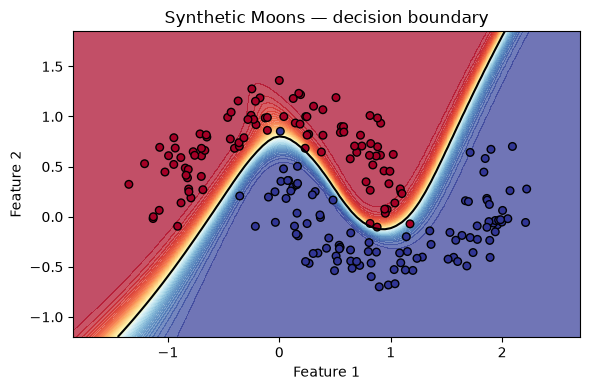


  Training on: Real Iris (Sepal)
  [  0] loss = 0.878871  acc = 96.0%
  [ 50] loss = 0.005950  acc = 100.0%
  [100] loss = 0.002375  acc = 100.0%
  [150] loss = 0.001283  acc = 100.0%
  [200] loss = 0.000893  acc = 100.0%
  [250] loss = 0.000667  acc = 100.0%
  [299] loss = 0.000506  acc = 100.0%


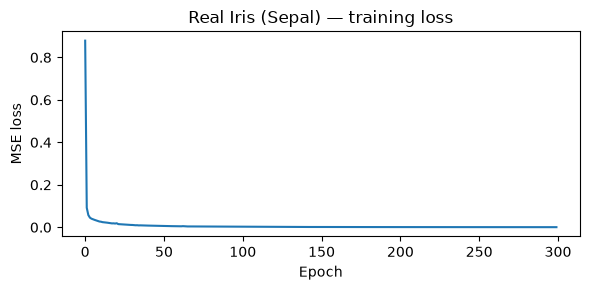

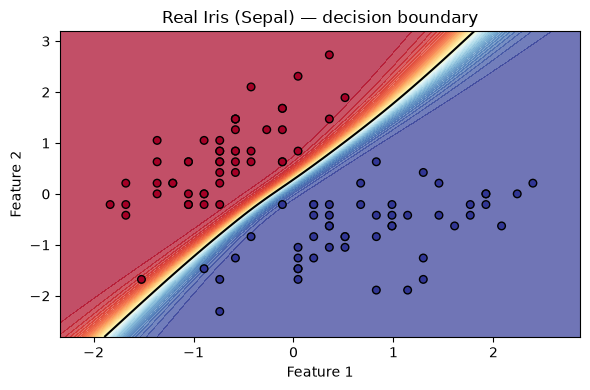

In [12]:
# ── Hyperparameters ────────────────────────────────────────────────────────────
LR         = 0.05     # learning rate  (lower than original to be more stable)
EPOCHS     = 300
BATCH_SIZE = 16
LOG_EVERY  = 50       # print full-dataset loss every N epochs

for name, X, y in datasets:
    print(f"\n{'='*55}")
    print(f"  Training on: {name}")
    print(f"{'='*55}")

    # Wrap numpy scalars in Params once (reused every epoch)
    xs = [[Params(float(x1), label=f"x0"), Params(float(x2), label=f"x1")]
          for x1, x2 in X]
    ys = [Params(float(yi), label="y") for yi in y]
    n_samples = len(xs)

    random.seed(42)
    model = MLP(2, [8, 8, 1])   # slightly wider hidden layers for harder datasets
    loss_history = []

    for epoch in range(EPOCHS):
        # ── Mini-batch SGD ────────────────────────────────────────────────────
        indices = list(range(n_samples))
        random.shuffle(indices)
        epoch_loss_sum = 0.0

        for start in range(0, n_samples, BATCH_SIZE):
            batch_idx  = indices[start : start + BATCH_SIZE]
            batch_xs   = [xs[i] for i in batch_idx]
            batch_ys   = [ys[i] for i in batch_idx]

            # Forward
            ypred = [model(x) for x in batch_xs]
            loss  = sum((yh - yt) ** 2 for yh, yt in zip(ypred, batch_ys))
            loss  = loss * (1.0 / len(batch_xs))

            # Backward  (zero BEFORE backward — avoids gradient accumulation)
            model.zero_grad()
            loss.backward()

            # Parameter update (vanilla SGD)
            for p in model.parameters():
                p.data -= LR * p.grad

            epoch_loss_sum += loss.data * len(batch_xs)

        # ── Epoch-level metrics (dedented out of the param loop) ──────────────
        epoch_loss = epoch_loss_sum / n_samples
        loss_history.append(epoch_loss)

        if epoch % LOG_EVERY == 0 or epoch == EPOCHS - 1:
            # Accuracy on full dataset
            correct = sum(
                1 for xi, yi in zip(xs, ys)
                if (model(xi).data >= 0) == (yi.data >= 0)
            )
            acc = correct / n_samples * 100
            print(f"  [{epoch:3d}] loss = {epoch_loss:.6f}  acc = {acc:.1f}%")

    # ── Post-training plots ───────────────────────────────────────────────────
    plt.figure(figsize=(6, 3))
    plt.plot(loss_history)
    plt.title(f"{name} — training loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE loss")
    plt.tight_layout()
    plt.show()

    plot_boundary(model, X, y, f"{name} — decision boundary")
